## 1. Lectura y ploteo de datos
Se lee dos tipos de archivos.
Datos de radar en formato `parquet` y otro archivo en `csv` que contiene las etiquetas de si hubo o no F dispersa ese dia . 

In [1]:
import pandas as pd
import os
from config import * 

cfg = Config()

## datos de radar
df_radar = pd.read_parquet(os.path.join(cfg.dir_dataset,"data.parquet"))
## datos de indicador si un dia hubo F dispersa.
labels_df = pd.read_csv("./dataset/annotated_data_sf.csv",parse_dates=['time'])

### 1.2 Ploteo de datos para visualización

t: 144
h: 40
data: (40, 144)


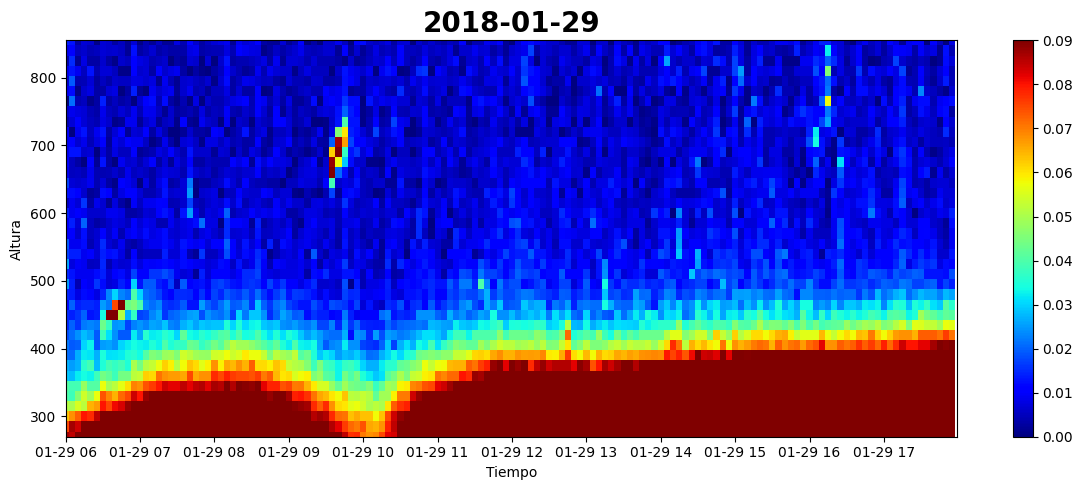

In [2]:
#### los datos ya se devuelven en tiempo local 
import matplotlib.pyplot as plt 
from datetime import datetime 
import numpy as np
import torch
import torch.nn as nn

import numpy as np
import pandas as pd


 
fecha = "2024-05-14"
fecha = "2018-01-29"

fecha_init = fecha + " 06:00:00.0"
fecha_fin = fecha + " 17:59:00.0"


def retrive_data(df_, i_t, f_t, dt="5min", dh=15):
    hmin = 270
    hmax = 855

    i_t = pd.to_datetime(i_t)
    f_t = pd.to_datetime(f_t)

    df = df_.copy()
    df = df.loc[df["time"].between(i_t, f_t)]
    df = df.loc[df["height"].between(hmin, hmax)]

    t_grid = pd.date_range(start=i_t, end=f_t, freq=dt)
    h_grid = np.arange(hmin, hmax + dh, dh)

    matrix = df.pivot_table(index="height", columns="time", values="value", aggfunc="mean")

    # reindex de columnas (tiempo) con tolerancia de, por ej., 2 min
    matrix = matrix.reindex(
        columns=t_grid,
        method="nearest",
        tolerance=pd.Timedelta("2min")
    )

    # reindex de filas (altura) con tolerancia de, por ej., 5 km
    matrix = matrix.reindex(
        index=h_grid,
        method="nearest",
        tolerance=5
    )

    t = matrix.columns.to_numpy()
    h = matrix.index.to_numpy()
    data = matrix.to_numpy()
    return t, h, data
    
t,h,data = retrive_data(df_radar,fecha_init,fecha_fin)

# Verificación opcional
print("t:", len(t))
print("h:", len(h))
print("data:", data.shape)

# ----------------------------------
# PLOT
# ----------------------------------

fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 1, 1)
vmax = np.nanpercentile(data, 85)

cc = ax.pcolormesh(
    t,
    h,
    data,
    cmap="jet",
    vmin=0,
    vmax=vmax,
    shading="auto"
)

fig.colorbar(cc, ax=ax)

ax.set_ylim(270, 855)

ax.set_xlabel("Tiempo")
ax.set_ylabel("Altura")


fecha_init = datetime.strptime(fecha_init,   "%Y-%m-%d %H:%M:%S.%f")
fecha_fin = datetime.strptime(fecha_fin,   "%Y-%m-%d %H:%M:%S.%f")


ax.set_xlim(fecha_init,fecha_fin)


ax.set_title(fecha,fontsize=20,fontweight='bold')

fig.tight_layout()

plt.show()

Solo se analizará en ciertos rangos, en este caso se plotea de `06-18 LT`. Debido a que si incluimos datos despues de este rango, escaparía el objetivo de predicción

## 2. Enfoque unica modalidad: Solo datos de radar

En esta sección analizaremos que tan bueno es el desempeño usando solamente datos de radar. Para ello, construiremos un modelo TF compatible con Masked Attention a fin de no darle importancia a regiones vacias que no contienen algún dato

In [3]:

def make_patch(t, h, data, d_horas, d_rango):
    patchs = []

    for i in range(12):  # eje x
        for j in range(4):  # eje y

            valid = True

            patch = data[d_rango * j: (j + 1) * d_rango, d_horas * (i):d_horas * (i + 1)]
            patch = patch.copy()

            threshold = d_horas * d_rango * 0.5
            count_nan = np.count_nonzero(np.isnan(patch))

            if count_nan > threshold:
                # creamos una mascara vacia
                ##print("Saltando patch")
                patch = np.zeros((d_rango, d_horas))
                valid = False
            elif count_nan > 0:
                ##print("No se salta patch")
                mask = np.isnan(patch)
                patch[mask] = 0  # or another value

            # padding
 
            patch = np.pad(
                patch,
                pad_width=((1, 1), (2, 2)),
                mode="constant",
                constant_values=0,
            )
 

            patchs.append((
                t[d_horas * (i):d_horas * (i + 1)],
                h[d_rango * j: (j + 1) * d_rango],
                patch, i, j, valid,
            ))
    return patchs


# ---------------------------------------------------------------------------
# Puente entre make_patch() y el modelo: convierte la lista de tuplas en
# tensores listos para PyTorch.
# ---------------------------------------------------------------------------

def patches_to_batch(patches_list):
    """
    patches_list: salida de make_patch(), lista de tuplas
        (t, h, patch, i, j, valid)

    Retorna (todo con batch=1, apilar afuera si tenes varias muestras):
        patches_t : (1, N, 1, H, W) float
        grid_i    : (N,) long          -> indice de tiempo del patch
        grid_j    : (N,) long          -> indice de altura del patch
        valid_mask: (1, N) bool        -> True = patch valido
    """
    imgs, idx_i, idx_j, valids = [], [], [], []
    for (_, _, patch, i, j, valid) in patches_list:
        imgs.append(patch)
        idx_i.append(i)
        idx_j.append(j)
        valids.append(valid)

    imgs = np.stack(imgs)[:, None, :, :]                       # (N, 1, H, W)
    patches_t = torch.from_numpy(imgs).float().unsqueeze(0)    # (1, N, 1, H, W)
    grid_i = torch.tensor(idx_i, dtype=torch.long)
    grid_j = torch.tensor(idx_j, dtype=torch.long)
    valid_mask = torch.tensor(valids, dtype=torch.bool).unsqueeze(0)  # (1, N)

    return patches_t, grid_i, grid_j, valid_mask


class PatchConvEmbed(nn.Module):
    ### transformación de patch a embedding mediante CNN 2D. 
    def __init__(self, patch_h, patch_w, embed_dim, in_chans=1):
        super().__init__()
        # kernel = tamaño exacto del patch -> cada patch produce 1 embedding
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=(patch_h, patch_w))

    def forward(self, patches):
        # patches: (B, N, C, H, W)
        B, N, C, H, W = patches.shape
        x = patches.view(B * N, C, H, W)
        x = self.proj(x)                 # (B*N, embed_dim, 1, 1)
        x = x.view(B, N, -1)             # (B, N, embed_dim)
        return x


class GridPosEmbed(nn.Module):
    """Positional embedding 2D aprendido, indexado por (i, j) de la grilla."""

    def __init__(self, n_time, n_height, embed_dim):
        super().__init__()
        self.pos = nn.Parameter(torch.zeros(n_time, n_height, embed_dim))
        nn.init.trunc_normal_(self.pos, std=0.02)

    def forward(self, grid_i, grid_j):
        return self.pos[grid_i, grid_j]  # (N, embed_dim)


 
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.drop1 = nn.Dropout(dropout)

        self.norm2 = nn.LayerNorm(embed_dim)
        hidden_dim = int(embed_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim),
        )
        self.drop2 = nn.Dropout(dropout)

    def forward(self, x, key_padding_mask=None):

        residual = x
        x_norm = self.norm1(x)

        ### mascara de atencion de cada uno
        attn_out, _ = self.attn(
            query=x_norm,
            key=x_norm,
            value=x_norm,
            key_padding_mask=key_padding_mask,  
            need_weights=False,
        )
        x = residual + self.drop1(attn_out)

        residual = x
        x_norm = self.norm2(x)
        x = residual + self.drop2(self.mlp(x_norm))

        return x


class TransformerEncoder(nn.Module):
    def __init__(self, embed_dim, num_heads, depth, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio, dropout)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x, key_padding_mask=None):
        for layer in self.layers:
            x = layer(x, key_padding_mask=key_padding_mask)
        return self.norm(x)




class MaskedRadarTransformer(nn.Module):
    def __init__(
        self,
        patch_h, patch_w,
        n_time=18, n_height=4,
        embed_dim=64, depth=4, num_heads=4,
        mlp_ratio=4.0, dropout=0.1,
        num_classes=1,
    ):
        super().__init__()
        self.patch_embed = PatchConvEmbed(patch_h, patch_w, embed_dim)
        self.pos_embed = GridPosEmbed(n_time, n_height, embed_dim)

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)

        self.encoder = TransformerEncoder(embed_dim, num_heads, depth, mlp_ratio, dropout)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, patches, grid_i, grid_j, valid_mask):
        """
        patches   : (B, N, 1, H, W)
        grid_i    : (N,)  indices de tiempo, iguales para todo el batch
        grid_j    : (N,)  indices de altura, iguales para todo el batch
        valid_mask: (B, N) bool, True = patch valido
        """
        B = patches.shape[0]

        x = self.patch_embed(patches)             # (B, N, D)
        pos = self.pos_embed(grid_i, grid_j)       # (N, D)
        x = x + pos.unsqueeze(0)

        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)             # (B, N+1, D)

        cls_valid = torch.ones(B, 1, dtype=torch.bool, device=x.device)
        valid_full = torch.cat([cls_valid, valid_mask], dim=1)
        key_padding_mask = ~valid_full             # True = invalido -> se ignora

        out = self.encoder(x, key_padding_mask=key_padding_mask)
        return self.head(out[:, 0])                # (B, num_classes)


In [3]:
## Estos valores nos representa cuantos pixeles ocupará cada patch. Estoy dividiendo patchs en horas de datos.

d_horas = int(((18 - 0) // 18) // (1 / 12))   # 12
d_rango = int(((900 - 250) // 4) // 15)  

HORA_INIT = 6
HORA_FIN  = 18

print("Formato esperado de datos:", (4 * d_rango, int(HORA_FIN - HORA_INIT)  * d_horas))

Formato esperado de datos: (40, 144)


In [16]:
def build_dataset(df_radar, labels_df, d_horas, d_rango, min_valid_frac=0.3):
    """
    Recorre cada fila de labels_df (columnas: time, spreadF_day), recupera
    el dia completo con retrive_data + make_patch, y descarta el dia si no
    llega al minimo de datos validos.
 
    Retorna:
        samples: lista de (patches_tensor (N,1,H,W), valid_mask (N,), label)
        grid_i, grid_j: indices de posicion (N,), iguales para todas las muestras
        skipped: lista de fechas descartadas con el motivo
    """
    samples = []
    sample_dates = []
    skipped = []
    grid_i, grid_j = None, None
 
    # orden cronologico explicito: el split 70/30 depende de este orden
    labels_df = labels_df.sort_values("time").reset_index(drop=True)
 
    for _, row in labels_df.iterrows():
        date = row["time"]
        label = row["spreadF_day"]
 
        fecha_init = date.strftime("%Y-%m-%d") + " 06:00:00.0"
        fecha_fin = date.strftime("%Y-%m-%d") + " 17:55:00.0"
 
        try:
            t, h, data = retrive_data(df_radar, fecha_init, fecha_fin)
        except Exception as e:
            skipped.append((date, f"error retrive_data: {e}"))
            continue
       
        # dia sin ningun registro en el radar
        expected_shape = (4 * d_rango, int(HORA_FIN - HORA_INIT)  * d_horas)

    
        if data.size == 0 or data.shape != expected_shape:
            skipped.append((date, f"shape inesperado {data.shape}, se esperaba {expected_shape}"))
            continue
 
        patches_list = make_patch(t, h, data, d_horas, d_rango)
 
        valid_flags = [p[5] for p in patches_list]
        valid_frac = float(np.mean(valid_flags))
        if valid_frac < min_valid_frac:
            skipped.append((date, f"valid_frac={valid_frac:.2f} < {min_valid_frac}"))
            continue
 
        if grid_i is None:
            grid_i = torch.tensor([p[3] for p in patches_list], dtype=torch.long)
            grid_j = torch.tensor([p[4] for p in patches_list], dtype=torch.long)
 
        imgs = np.stack([p[2] for p in patches_list])[:, None, :, :]  # (N,1,H,W)
        patches_tensor = torch.from_numpy(imgs).float()
        valid_mask = torch.tensor(valid_flags, dtype=torch.bool)
 
        samples.append((patches_tensor, valid_mask, int(label)))
        sample_dates.append(date)
 
    return samples, sample_dates, grid_i, grid_j, skipped

In [17]:
samples, sample_dates, grid_i, grid_j, skipped  = build_dataset(df_radar.copy(), labels_df.copy(), d_horas, d_rango, min_valid_frac=0.3)

In [18]:
print(f"Dias usables: {len(samples)} | Dias descartados: {len(skipped)}")

## Estos dias han sido descartado por falta de datos o datos vacios

Dias usables: 188 | Dias descartados: 24


In [19]:
test_size = 0.2

n_train = int(len(samples) * (1 - test_size))
train_samples = samples[:n_train]
test_samples = samples[n_train:]

print(f"Train: {sample_dates[0].date()} a {sample_dates[n_train - 1].date()} "
      f"({len(train_samples)} dias)")
print(f"Test:  {sample_dates[n_train].date()} a {sample_dates[-1].date()} "
      f"({len(test_samples)} dias)")



Train: 2014-01-21 a 2021-09-24 (150 dias)
Test:  2021-09-25 a 2024-05-16 (38 dias)


In [23]:
from torch.utils.data import Dataset, DataLoader

import math
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
 
 
class RadarDataset(Dataset):
    def __init__(self, samples, mean=0.0, std=1.0,normalize_data=True):
        self.samples = samples
        self.mean = mean
        self.std = std
        self.norm = normalize_data
 
    def __len__(self):
        return len(self.samples)
 
    def __getitem__(self, idx):

        
        patches, valid_mask, label = self.samples[idx]
        if self.norm:
            patches = (patches - self.mean) / self.std
        return patches, valid_mask, torch.tensor(label, dtype=torch.float32)
 
 
def compute_train_stats(samples):
    """Media/std SOLO sobre pixeles validos del set de train (evita leakage)."""
    vals = []
    for patches, valid_mask, _ in samples:
        # patches: (N,1,H,W), valid_mask: (N,)
        valid_patches = patches[valid_mask]
        if valid_patches.numel() > 0:
            vals.append(valid_patches.flatten())
    all_vals = torch.cat(vals)
    return all_vals.mean().item(), all_vals.std().item() + 1e-6
 
 
# ---------------------------------------------------------------------------
# 2. Warmup + cosine decay
# ---------------------------------------------------------------------------
 
def make_warmup_cosine_scheduler(optimizer, warmup_steps, total_steps):
    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * min(progress, 1.0)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
 
 
# ---------------------------------------------------------------------------
# 3. Loop de entrenamiento
# ---------------------------------------------------------------------------
 
def train(
    df_radar, labels_df,
    d_horas, d_rango,
    min_valid_frac=0.3,
    test_size=0.3,
    embed_dim=64, depth=2, num_heads=4, dropout=0.1,
    batch_size=8, epochs=20, lr=3e-4, warmup_frac=0.1,
    seed=42, device=None, normalize_data=True
):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    torch.manual_seed(seed)
 
    # --- construir dataset y filtrar dias con poco dato ---
    samples, sample_dates, grid_i, grid_j, skipped = build_dataset(
        df_radar, labels_df, d_horas, d_rango, min_valid_frac
    )
    print(f"Dias usables: {len(samples)} | Dias descartados: {len(skipped)}")
    for date, reason in skipped:
        print(f"  descartado {date}: {reason}")
 
    if len(samples) < 10:
        raise ValueError("Muy pocas muestras utilizables para entrenar de forma confiable.")
 
    # --- split 70/30 CRONOLOGICO: se mantiene el orden de las fechas, sin
    # mezclar. Los dias mas antiguos van a train, los mas recientes a test.
    # build_dataset ya devuelve samples/sample_dates ordenados por fecha. ---
    n_train = int(len(samples) * (1 - test_size))
    train_samples = samples[:n_train]
    test_samples = samples[n_train:]
 
    print(f"Train: {sample_dates[0].date()} a {sample_dates[n_train - 1].date()} "
          f"({len(train_samples)} dias)")
    print(f"Test:  {sample_dates[n_train].date()} a {sample_dates[-1].date()} "
          f"({len(test_samples)} dias)")
 
    # --- normalizacion SOLO con estadisticas de train ---
    mean, std = compute_train_stats(train_samples)
    print(f"Normalizacion (train): mean={mean:.4f}, std={std:.4f}")
 
    train_ds = RadarDataset(train_samples, mean, std,normalize_data=normalize_data)
    test_ds = RadarDataset(test_samples, mean, std,normalize_data=normalize_data)
 
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
 
    # --- pos_weight para compensar desbalance de clases ---
    train_labels = np.array([s[2] for s in train_samples])
    n_pos = max(1, (train_labels == 1).sum())
    n_neg = max(1, (train_labels == 0).sum())
    pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32, device=device)
    print(f"Train: {n_neg} negativos, {n_pos} positivos -> pos_weight={pos_weight.item():.2f}")
 
    # --- modelo ---
    patch_h, patch_w = samples[0][0].shape[-2], samples[0][0].shape[-1]
    model = MaskedRadarTransformer(
        patch_h=patch_h, patch_w=patch_w,
        n_time=18, n_height=4,
        embed_dim=embed_dim, depth=depth, num_heads=num_heads, dropout=dropout,
        num_classes=1,
    ).to(device)
 
    grid_i, grid_j = grid_i.to(device), grid_j.to(device)
 
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = epochs * len(train_loader)
    warmup_steps = max(1, int(total_steps * warmup_frac))
    scheduler = make_warmup_cosine_scheduler(optimizer, warmup_steps, total_steps)
 
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
 
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for patches, valid_mask, labels in train_loader:
            patches = patches.to(device)
            valid_mask = valid_mask.to(device)
            labels = labels.to(device)
 
            logits = model(patches, grid_i, grid_j, valid_mask).squeeze(-1)
            loss = criterion(logits, labels)
 
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
 
            total_loss += loss.item() * patches.size(0)
 
        train_loss = total_loss / len(train_ds)
 
        # --- evaluacion ---
        model.eval()
        correct, total, test_loss = 0, 0, 0.0
        with torch.no_grad():
            for patches, valid_mask, labels in test_loader:
                patches = patches.to(device)
                valid_mask = valid_mask.to(device)
                labels = labels.to(device)
 
                logits = model(patches, grid_i, grid_j, valid_mask).squeeze(-1)
                loss = criterion(logits, labels)
                test_loss += loss.item() * patches.size(0)
 
                preds = (torch.sigmoid(logits) > 0.7).float()
                correct += (preds == labels).sum().item()
                total += labels.size(0)
 
        test_loss /= max(1, len(test_ds))
        acc = correct / max(1, total)
        current_lr = scheduler.get_last_lr()[0]
        print(f"Epoch {epoch+1:3d}/{epochs} | lr={current_lr:.2e} | "
              f"train_loss={train_loss:.4f} | test_loss={test_loss:.4f} | test_acc={acc:.3f}")
 
    return model, (mean, std), (grid_i, grid_j)
 
 
# ---------------------------------------------------------------------------
# Prueba end-to-end con datos sinteticos
# ---------------------------------------------------------------------------
 

In [26]:
train(df_radar.copy(), labels_df.copy(), d_horas, d_rango,depth=2,test_size=0.1,normalize_data=False,
     batch_size=2, epochs=1000, lr=1e-4, warmup_frac=0.2,)

Dias usables: 188 | Dias descartados: 24
  descartado 2014-01-20 00:00:00: valid_frac=0.08 < 0.3
  descartado 2015-03-27 00:00:00: valid_frac=0.17 < 0.3
  descartado 2015-12-09 00:00:00: valid_frac=0.00 < 0.3
  descartado 2016-01-04 00:00:00: valid_frac=0.17 < 0.3
  descartado 2016-03-14 00:00:00: valid_frac=0.00 < 0.3
  descartado 2016-11-28 00:00:00: valid_frac=0.08 < 0.3
  descartado 2016-12-03 00:00:00: valid_frac=0.17 < 0.3
  descartado 2017-01-05 00:00:00: valid_frac=0.17 < 0.3
  descartado 2017-01-27 00:00:00: valid_frac=0.17 < 0.3
  descartado 2018-01-10 00:00:00: valid_frac=0.25 < 0.3
  descartado 2018-01-22 00:00:00: valid_frac=0.08 < 0.3
  descartado 2018-02-03 00:00:00: valid_frac=0.17 < 0.3
  descartado 2018-04-02 00:00:00: valid_frac=0.25 < 0.3
  descartado 2018-07-18 00:00:00: valid_frac=0.25 < 0.3
  descartado 2018-12-26 00:00:00: valid_frac=0.00 < 0.3
  descartado 2019-12-02 00:00:00: valid_frac=0.25 < 0.3
  descartado 2020-01-13 00:00:00: valid_frac=0.25 < 0.3
  desca

(MaskedRadarTransformer(
   (patch_embed): PatchConvEmbed(
     (proj): Conv2d(1, 64, kernel_size=(12, 16), stride=(1, 1))
   )
   (pos_embed): GridPosEmbed()
   (encoder): TransformerEncoder(
     (layers): ModuleList(
       (0-1): 2 x TransformerBlock(
         (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
         (attn): MultiheadAttention(
           (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
         )
         (drop1): Dropout(p=0.1, inplace=False)
         (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
         (mlp): Sequential(
           (0): Linear(in_features=64, out_features=256, bias=True)
           (1): GELU(approximate='none')
           (2): Dropout(p=0.1, inplace=False)
           (3): Linear(in_features=256, out_features=64, bias=True)
         )
         (drop2): Dropout(p=0.1, inplace=False)
       )
     )
     (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
   )
   (head):

## Analisis unimodal: Solo usando series de datos

Analizamos usando diferentes series de datos

In [4]:
def get_index_data(df,fecha_init,fecha_fin):
    
    time_grid = pd.date_range(
        start=fecha_init,
        end=fecha_fin,
        freq="5min"
    )
    df = (
        df.set_index("fecha_LT")
          .reindex(
              time_grid,
              method="nearest",
              tolerance=pd.Timedelta("30min")
          )
          .rename_axis("fecha_LT")
          .reset_index()
    )
    return df 

In [5]:
df_indexes = pd.read_parquet("./dataset/indexes.parquet")
df_indexes.head(5)

### creamos la columna sin, cos de doy y hour

df_indexes["hour_LT"] = df_indexes["fecha_LT"].dt.hour + df_indexes["fecha_LT"].dt.minute / 60

df_indexes["doy_LT"] = df_indexes["fecha_LT"].dt.dayofyear

# Codificación cíclica de hora
df_indexes["hour_sin"] = np.sin(2 * np.pi * df_indexes["hour_LT"] / 24)
df_indexes["hour_cos"] = np.cos(2 * np.pi * df_indexes["hour_LT"] / 24)

# Codificación cíclica de día del año
df_indexes["doy_sin"] = np.sin(2 * np.pi * df_indexes["doy_LT"] / 366)
df_indexes["doy_cos"] = np.cos(2 * np.pi * df_indexes["doy_LT"] / 366)

df_indexes.head(4)

,fecha[UTC],F10.7obs,F10.7adj,ap,Kp,flux,symH,Bz,fecha_LT,hour_LT,doy_LT,hour_sin,hour_cos,doy_sin,doy_cos
0,1932-01-01 00:00:00,-1.0,-1.0,18.0,3.333,NaN,NaN,NaN,1931-12-31 19:00:00-05:00,19.000000,365,-0.965926,0.258819,-0.017166,0.999853
1,1932-01-01 00:05:00,-1.0,-1.0,18.0,3.333,NaN,NaN,NaN,1931-12-31 19:05:00-05:00,19.083333,365,-0.960050,0.279829,-0.017166,0.999853
2,1932-01-01 00:10:00,-1.0,-1.0,18.0,3.333,NaN,NaN,NaN,1931-12-31 19:10:00-05:00,19.166667,365,-0.953717,0.300706,-0.017166,0.999853
3,1932-01-01 00:15:00,-1.0,-1.0,18.0,3.333,NaN,NaN,NaN,1931-12-31 19:15:00-05:00,19.250000,365,-0.946930,0.321439,-0.017166,0.999853


## Visualización de datos

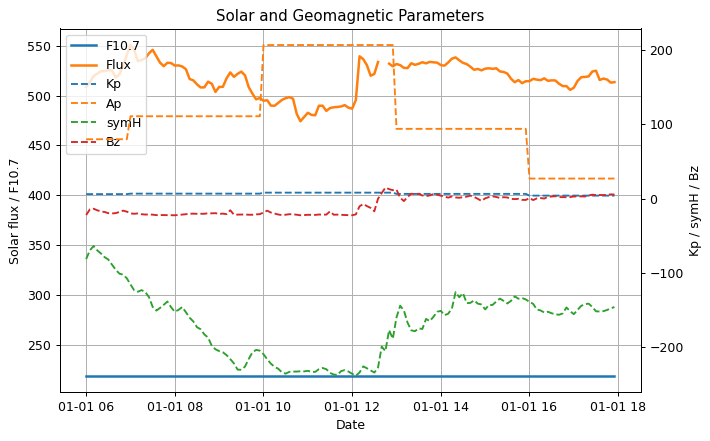

In [6]:
import matplotlib.pyplot as plt

fecha = "2025-1-1"

fecha_init = pd.Timestamp(fecha + " 06:00:00.0", tz="America/Lima")
fecha_fin  = pd.Timestamp(fecha + " 17:59:59.0", tz="America/Lima")

df = get_index_data(df_indexes.copy(),fecha_init,fecha_fin)

fig = plt.figure(figsize=(8, 5), dpi=90)

f107 = df["F10.7obs"].values
kp= df["Kp"].values
ap = df["ap"].values
flux = df["flux"].values
symH = df["symH"].values
Bz = df["Bz"].values

time = df["fecha_LT"]  # si tienes fecha como índice

# Primer eje
ax = fig.add_subplot(111)

ax.plot(time, f107, label="F10.7", linewidth=2)
ax.plot(time, flux, label="Flux", linewidth=2)

ax.set_xlabel("Date")
ax.set_ylabel("Solar flux / F10.7")
ax.grid(True)

# Segundo eje
ax2 = ax.twinx()

ax2.plot(time, kp, label="Kp", linestyle="--")
ax2.plot(time, ap, label="Ap", linestyle="--")
ax2.plot(time, symH, label="symH", linestyle="--")
ax2.plot(time, Bz, label="Bz", linestyle="--")

ax2.set_ylabel("Kp / symH / Bz")

# Combinar leyendas de ambos ejes
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax.legend(
    lines + lines2,
    labels + labels2,
    loc="upper left"
)

plt.title("Solar and Geomagnetic Parameters")
plt.tight_layout()
plt.show()

In [7]:
def check_dataset(df_indexes_, labels_df_,verbose=0):

    """
    Analizamos si está completo la cantidad de datos de un dia, si no lo está lo descartamos para 
    estimación.
    
    """

    samples_dates = list()
    skipped = list()
    df_indexes = df_indexes_.copy()

    labels = []
    
    labels_df = labels_df_.copy()

    labels_df = labels_df.sort_values("time").reset_index(drop=True)
 
    for _, row in labels_df.iterrows():
        date = row["time"]
        label = row["spreadF_day"]

        if verbose:
            print("Date:",date)
        
        fecha_init = date.replace(hour=6, minute=0, second=0)
        fecha_fin  = date.replace(hour=17, minute=59, second=59)

        fecha_init = fecha_init.tz_localize("America/Lima")
        fecha_fin = fecha_fin.tz_localize("America/Lima")

        try:
            df = get_index_data(df_indexes.copy(), fecha_init, fecha_fin)
        except Exception as e:
        
            print("Saltando:",e)
 
            skipped.append((date, f"error retrive_data: {e}"))
            continue

        count_valid = len(df.dropna())
        count_total = len(df)

        if (count_valid<0.5*count_total):
            if verbose:
                print(f"Saltando date: {date} por falta de datos.")
                print(count_valid,count_total)
            skipped.append((date, "error falta de datos"))
            continue

        samples_dates.append((date,label))
    return samples_dates,skipped
dataset ,skipped= check_dataset(df_indexes,labels_df)

In [8]:
print(f"Dias usables: {len(dataset)} | Dias descartados: {len(skipped)}")


Dias usables: 208 | Dias descartados: 4


In [9]:
test_size = 0.2 ##sacamos el 20% de datos 

n_train = int(len(dataset) * (1 - test_size))
train_samples = dataset[:n_train]
test_samples = dataset[n_train:]

print(f"Train: {dataset[0][0].date()} a {dataset[n_train - 1][0].date()} "
      f"({len(train_samples)} dias)")
print(f"Test:  {dataset[n_train][0].date()} a {dataset[-1][0].date()} "
      f"({len(test_samples)} dias)")


Train: 2014-01-20 a 2021-09-24 (166 dias)
Test:  2021-09-25 a 2024-05-17 (42 dias)


In [13]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader

class IntradayDataset(Dataset):
    """
    Convierte cada (fecha, label) en:
        x     -> (seq_len, n_features)  serie intradía (NaN -> 0)
        mask  -> (seq_len,)             1 = dato real, 0 = dato faltante
        y     -> label (spreadF_day)
 
    Todas las secuencias comparten el mismo largo (mismo grid horario
    06:00-17:59), por lo que no se necesita padding entre muestras,
    solo el masking de los timesteps faltantes dentro del día.
    """
 
    def __init__(self, samples, df_indexes, feature_cols, freq="5min",
                 scaler=None, include_mask_as_feature=True):
        self.samples = samples
        self.df_indexes = df_indexes
        self.feature_cols = feature_cols
        self.freq = freq
        self.scaler = scaler
        self.include_mask_as_feature = include_mask_as_feature
        self.max_len = self._compute_grid_len()
 
    def _compute_grid_len(self):
        grid = pd.date_range("2000-01-01 06:00:00", "2000-01-01 17:59:00", freq=self.freq)
        return len(grid)
 
    def __len__(self):
        return len(self.samples)
 
    def _get_day_data(self, date):
        fecha_init = date.replace(hour=6, minute=0, second=0).tz_localize("America/Lima")
        fecha_fin = date.replace(hour=17, minute=59, second=59).tz_localize("America/Lima")
 
        df = get_index_data(self.df_indexes.copy(), fecha_init, fecha_fin)
        df = df[self.feature_cols] ## Seleccionamos las columnas a usar


        mask = (~df.isna().any(axis=1)).astype(np.float32).values  # 1 = valido
        x = df.fillna(0.0).values.astype(np.float32) ## Rellenamos con 0 los valores nan y pasamos a tipo float 32 todas las variables
        return x, mask
 
    def __getitem__(self, idx):
        date, label = self.samples[idx]
        x, mask = self._get_day_data(date)
 
        if self.scaler is not None:
            x = self.scaler.transform(x)
 
        if self.include_mask_as_feature:
            x = np.concatenate([x, mask.reshape(-1, 1)], axis=1)
 
        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(mask, dtype=torch.float32),
            torch.tensor(label, dtype=torch.float32),
        )
 
 
def fit_scaler(samples, df_indexes, feature_cols, freq="1min"):
    """Ajusta un StandardScaler solo con los datos de entrenamiento."""
    tmp_ds = IntradayDataset(samples, df_indexes, feature_cols, freq=freq,
                              scaler=None, include_mask_as_feature=False)
    all_rows = []
    for i in range(len(tmp_ds)):
        date, _ = tmp_ds.samples[i]
        x, mask = tmp_ds._get_day_data(date)
        all_rows.append(x[mask.astype(bool)])  ## solo con datos reales
    all_rows = np.concatenate(all_rows, axis=0)
    scaler = StandardScaler()
    scaler.fit(all_rows)
    return scaler
 
 
# ---------------------------------------------------------------------------
# 3. Modelo LSTM + masking + FeedForward
# ---------------------------------------------------------------------------
class MaskedLSTMFeedForward(nn.Module):
    """
    Masked LSTM al estilo de Keras.
    
    """
    
    def __init__(self, input_size, hidden_size=64, num_layers=1,
                 ff_hidden=32, output_size=1, dropout=0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # una LSTMCell por capa, para poder apilar num_layers > 1
        self.cells = nn.ModuleList([
            nn.LSTMCell(input_size if i == 0 else hidden_size, hidden_size)
            for i in range(num_layers)
        ]) ## esto está bien
        self.dropout = nn.Dropout(dropout)

        self.ff = nn.Sequential(
            nn.Linear(hidden_size, ff_hidden),
            nn.ReLU(),
            #nn.Dropout(dropout),
            nn.Linear(ff_hidden, output_size),
        )

    def forward(self, x, mask):

        batch, seq_len, _ = x.shape
    
        h = [x.new_zeros(batch, self.hidden_size) for _ in range(self.num_layers)]
        c = [x.new_zeros(batch, self.hidden_size) for _ in range(self.num_layers)]
    
        outputs = []
        for t in range(seq_len):
            inp = x[:, t, :]
            m = mask[:, t].unsqueeze(-1)
    
            for layer in range(self.num_layers):
                h_new, c_new = self.cells[layer](inp, (h[layer], c[layer]))
                h[layer] = m * h_new + (1 - m) * h[layer]
                c[layer] = m * c_new + (1 - m) * c[layer]
                inp = h[layer]
                if layer < self.num_layers - 1:
                    inp = self.dropout(inp)
    
            outputs.append(h[-1])
    
        out = torch.stack(outputs, dim=1)  # (batch, seq_len, hidden)
    
        idx_range = torch.arange(1,seq_len + 1, device=x.device).unsqueeze(0)   # (1, seq_len)
        valid_idx = idx_range * mask                                      # pone 0 donde es invalido
        last_valid_idx = valid_idx.max(dim=1).values.long()   -1             # (batch,) indice mas alto con mask=1
    
        # gather: para cada muestra, tomar out[i, last_valid_idx[i], :]
        pooled = out[torch.arange(batch, device=x.device), last_valid_idx]  # (batch, hidden)
    
        logits = self.ff(pooled)
        return logits.squeeze(-1)

        
        """
        x:    (batch, seq_len, input_size)
        mask: (batch, seq_len)  1 = valido, 0 = faltante
        """

        """
        batch, seq_len, _ = x.shape
        device = x.device

        h = [x.new_zeros(batch, self.hidden_size) for _ in range(self.num_layers)]
        c = [x.new_zeros(batch, self.hidden_size) for _ in range(self.num_layers)]

        outputs = []

        for t in range(seq_len):
            inp = x[:, t, :]
            m = mask[:, t].unsqueeze(-1)  # (batch, 1)

            for layer in range(self.num_layers):
                h_new, c_new = self.cells[layer](inp, (h[layer], c[layer]))
                # si el timestep es invalido, congelamos el estado (no avanza)
                h[layer] = m * h_new + (1 - m) * h[layer]
                c[layer] = m * c_new + (1 - m) * c[layer]
                inp = h[layer]
                if layer < self.num_layers - 1:
                    inp = self.dropout(inp)

            outputs.append(h[-1])  # salida de la ultima capa en este timestep

        out = torch.stack(outputs, dim=1)  # (batch, seq_len, hidden)

        ### aqui calcula el promedio de todos los estados ocultos.
        ### lo voy a comentar, no creo que sea la mejor implementación
        ### 1 2 3 --- esto no es IA

        """
        """
        mask_exp = mask.unsqueeze(-1)
        summed = (out * mask_exp).sum(dim=1)
        counts = mask.sum(dim=1, keepdim=True).clamp(min=1.0)
        pooled = summed / counts
        """
        """

        
        #logits = self.ff(pooled)
        #return logits.squeeze(-1)
        """
# ---------------------------------------------------------------------------
# 4. Entrenamiento / evaluación
# ---------------------------------------------------------------------------
import time
import sys
import torch
import torch.nn as nn


def train_model(model, train_loader, test_loader, epochs=30, lr=1e-5, device="cuda"):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    n_batches = len(train_loader)
    bar_len = 30  # longitud de la barra de progreso

    for epoch in range(1, epochs + 1):
        print(f"Epoch {epoch}/{epochs}")

        # ---------------- TRAIN ----------------
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        epoch_start = time.time()

        for batch_idx, (x, mask, y) in enumerate(train_loader, start=1):
            x, mask, y = x.to(device), mask.to(device), y.to(device).float()

            optimizer.zero_grad()
            preds = model(x, mask).view(-1)
            y = y.view(-1)
            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()

            batch_size = x.size(0)
            train_loss += loss.item() * batch_size
            probs = torch.sigmoid(preds)
            train_correct += ((probs > 0.5).float() == y).sum().item()
            train_total += batch_size

            # --- métricas parciales para mostrar en vivo ---
            running_loss = train_loss / train_total
            running_acc = train_correct / train_total

            # --- barra de progreso estilo Keras ---
            progress = batch_idx / n_batches
            filled = int(bar_len * progress)
            bar = "=" * filled + (">" if filled < bar_len else "") + "." * (bar_len - filled - 1)
            elapsed = time.time() - epoch_start
            eta = elapsed / batch_idx * (n_batches - batch_idx)

            sys.stdout.write(
                f"\r{batch_idx}/{n_batches} [{bar}] - ETA: {eta:0.0f}s "
                f"- loss: {running_loss:.4f} - acc: {running_acc:.4f}"
            )
            sys.stdout.flush()

        train_loss /= train_total
        train_acc = train_correct / train_total
        epoch_time = time.time() - epoch_start

        # ---------------- VALIDACIÓN ----------------
        model.eval()
        test_loss, test_correct, test_total = 0.0, 0, 0
        with torch.no_grad():
            for x, mask, y in test_loader:
                x, mask, y = x.to(device), mask.to(device), y.to(device).float()
                preds = model(x, mask).view(-1)
                y = y.view(-1)
                loss = criterion(preds, y)

                batch_size = x.size(0)
                test_loss += loss.item() * batch_size
                probs = torch.sigmoid(preds)
                test_correct += ((probs > 0.5).float() == y).sum().item()
                test_total += batch_size

        test_loss /= test_total
        test_acc = test_correct / test_total

        # --- línea final del epoch (reemplaza la barra en progreso) ---
        bar_full = "=" * bar_len
        sys.stdout.write(
            f"\r{n_batches}/{n_batches} [{bar_full}] - {epoch_time:0.0f}s "
            f"- loss: {train_loss:.4f} - acc: {train_acc:.4f} "
            f"- val_loss: {test_loss:.4f} - val_acc: {test_acc:.4f}\n"
        )
        sys.stdout.flush()

    return model

In [14]:
keys_to_train = ["Kp",
                "ap",
                "flux",
                "symH",
                "Bz",
                "hour_sin",
                "hour_cos",
                "doy_sin",
                "doy_cos",]


ds_train = IntradayDataset(train_samples,df_indexes,keys_to_train)
ds_val = IntradayDataset(test_samples,df_indexes,keys_to_train)

train_loader = DataLoader(ds_train, batch_size=64, shuffle=True)
test_loader  = DataLoader(ds_val, batch_size=64, shuffle=False)


n_features = ds_train[0][0].shape[-1]
 

model = MaskedLSTMFeedForward(
    input_size=n_features,
    hidden_size=64,
    num_layers=1,
    ff_hidden=32,
    output_size=1,   # para binaria, 1 logit está bien
 
)

train_model(model,train_loader,test_loader)

Epoch 1/30
3/3 [==============================] - 79s - loss: 0.5578 - acc: 0.9157 - val_loss: 0.7161 - val_acc: 0.4762
Epoch 2/30
3/3 [==============================] - 79s - loss: 0.5575 - acc: 0.9157 - val_loss: 0.7162 - val_acc: 0.4762
Epoch 3/30
3/3 [==============================] - 80s - loss: 0.5572 - acc: 0.9157 - val_loss: 0.7163 - val_acc: 0.4762
Epoch 4/30
3/3 [==============================] - 79s - loss: 0.5569 - acc: 0.9157 - val_loss: 0.7165 - val_acc: 0.4762
Epoch 5/30
3/3 [==============================] - 80s - loss: 0.5566 - acc: 0.9157 - val_loss: 0.7166 - val_acc: 0.4762
Epoch 6/30
3/3 [==============================] - 79s - loss: 0.5563 - acc: 0.9157 - val_loss: 0.7167 - val_acc: 0.4762
Epoch 7/30
3/3 [==============================] - 79s - loss: 0.5560 - acc: 0.9157 - val_loss: 0.7168 - val_acc: 0.4762
Epoch 8/30
3/3 [==============================] - 79s - loss: 0.5557 - acc: 0.9157 - val_loss: 0.7170 - val_acc: 0.4762
Epoch 9/30
3/3 [========================

MaskedLSTMFeedForward(
  (cells): ModuleList(
    (0): LSTMCell(10, 64)
  )
  (dropout): Dropout(p=0.2, inplace=False)
  (ff): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)